In [1]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE, ADASYN # Adicione ADASYN
# from imblearn.combine import SMOTETomek # Opcional: para over e undersampling combinados
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # Opcional: para outros modelos

# 📌 2. Carregar os dados
df = pd.read_csv("./INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)


In [2]:
# 📌 3. Pré-processamento Aprimorado
# Filtrar apenas os registros com evolução "Cura (1)" e "Óbito (2)"
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()

# Mapear valores: 1 → 0 (Cura), 2 → 1 (Óbito)
df_filtered.loc[:, 'EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

# Lista de colunas com fatores de risco
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Converter '9' para NaN para os fatores de risco.
# O `.dropna()` posterior removerá as linhas com NaN nessas colunas.
df_filtered.loc[:, fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')

# Tratamento da coluna NU_IDADE_N (Idade)
# Converte para numérico. Valores não numéricos se tornam NaN.
df_filtered.loc[:, 'NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')

# Tratamento da coluna CS_SEXO (Sexo)
# Mapeia 'M' para 0 e 'F' para 1. 'I' (Ignorado) e outros valores se tornam NaN.
df_filtered.loc[:, 'CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})
# Para 'I' (Ignorado), Deixei como NaN e remover na etapa de dropna

# Remover linhas com valores ausentes nas colunas essenciais
# Isso garantirá que estamos usando apenas registros completos para essas features.
colunas_essenciais = fatores_risco + ['EVOLUCAO', 'NU_IDADE_N', 'CS_SEXO']
df_filtered.dropna(subset=colunas_essenciais, inplace=True)

# Separar variáveis preditoras (X) e variável alvo (y)
# Adicione 'NU_IDADE_N' e 'CS_SEXO' à sua lista de features preditoras.
X = df_filtered[fatores_risco + ['NU_IDADE_N', 'CS_SEXO']]
y = df_filtered['EVOLUCAO']

# Verificação das primeiras linhas de X e y após o pré-processamento
print("Primeiras linhas de X após pré-processamento:")
print(X.head())
print("\nDistribuição de y após pré-processamento:")
print(y.value_counts())

Primeiras linhas de X após pré-processamento:
    PUERPERA  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  \
3        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
9        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
10       2.0         1.0         2.0        2.0       2.0   2.0       2.0   
12       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
14       2.0         2.0         2.0        2.0       2.0   2.0       2.0   

    NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE  OUT_MORBI  \
3          2.0         2.0         2.0    2.0        2.0        1.0   
9          2.0         2.0         2.0    2.0        2.0        2.0   
10         2.0         2.0         2.0    2.0        2.0        1.0   
12         2.0         2.0         1.0    2.0        2.0        1.0   
14         2.0         1.0         2.0    2.0        2.0        2.0   

    NU_IDADE_N CS_SEXO  
3           72     0.0  
9           63

In [3]:
# 📌 4. Balanceamento (Experimentar ADASYN ou class_weight)
print(f"Balanceamento antes: \n{y.value_counts()}")

#SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Balanceamento depois: \n{y_res.value_counts()}")

Balanceamento antes: 
EVOLUCAO
0.0    50301
1.0     9533
Name: count, dtype: int64
Balanceamento depois: 
EVOLUCAO
1.0    50301
0.0    50301
Name: count, dtype: int64


In [4]:
# 📌 5. Treinamento e Otimização do Modelo (com Validação Cruzada e Grid Search)
# Divisão em treino e teste (mantida para avaliação final, mas validação cruzada será usada no Grid Search)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res) # stratify para manter proporção

# **Aprimoramento 3: Grid Search para encontrar os melhores hiperparâmetros**
clf = DecisionTreeClassifier(random_state=42)

# Definir os parâmetros a serem testados
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # None = profundidade total
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy']
}

# Usar StratifiedKFold para validação cruzada, mantendo a proporção de classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar o GridSearchCV
# O scoring deve ser baseado na métrica que você mais valoriza (ex: 'f1' para a classe minoritária, 'recall' para 'óbitos')
# 'f1_macro' ou 'f1_weighted' são boas opções para balancear ambas as classes
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (macro) na validação cruzada: {grid_search.best_score_:.4f}")

# Obter o melhor modelo
best_clf = grid_search.best_estimator_

# talvez TREINAR OUTROS MODELOS ***

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Melhor F1-Score (macro) na validação cruzada: 0.7621


In [5]:
# 📌 6. Avaliação Abrangente
y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1] # Probabilidades para a classe positiva (Óbito)

print("\n--- Avaliação do Melhor Modelo CART ---")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

# Calcular Métricas Específicas para Óbito (Classe 1)
precision_óbitos = precision_score(y_test, y_pred, pos_label=1)
recall_óbitos = recall_score(y_test, y_pred, pos_label=1)
f1_óbitos = f1_score(y_test, y_pred, pos_label=1)

print(f"\nPrecisão para Óbito: {precision_óbitos:.2f}")
print(f"Recall para Óbito: {recall_óbitos:.2f}")
print(f"F1-Score para Óbito: {f1_óbitos:.2f}")


--- Avaliação do Melhor Modelo CART ---
📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.73      0.76     15091
         1.0       0.75      0.81      0.78     15090

    accuracy                           0.77     30181
   macro avg       0.77      0.77      0.77     30181
weighted avg       0.77      0.77      0.77     30181


Precisão para Óbito: 0.75
Recall para Óbito: 0.81
F1-Score para Óbito: 0.78



Matriz de Confusão:


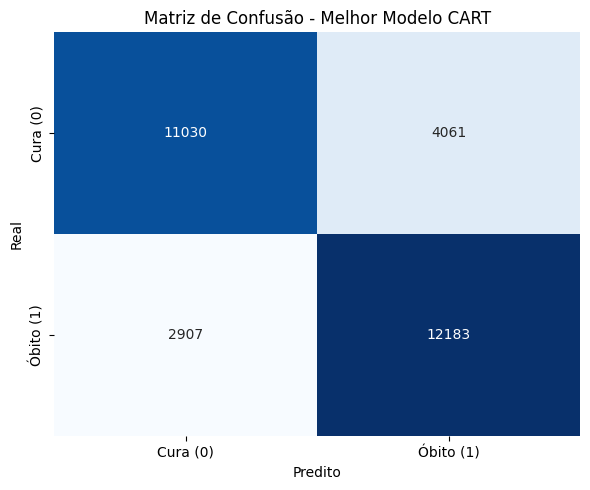

In [6]:
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Melhor Modelo CART')
plt.tight_layout()
plt.show()

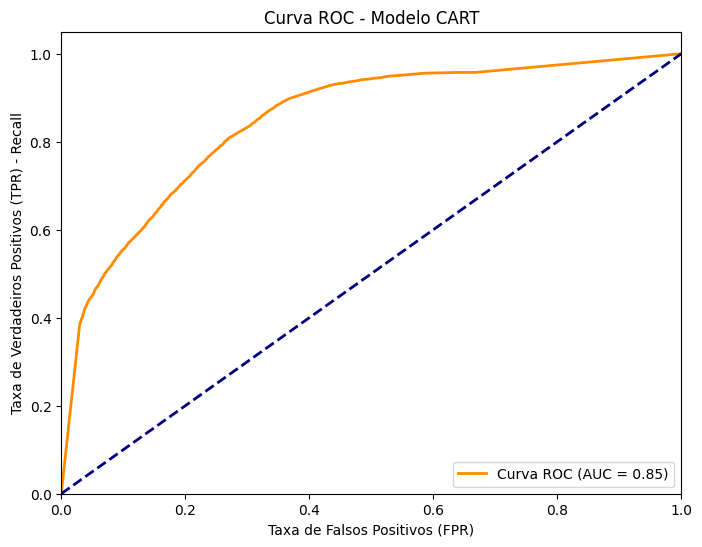


AUC do Modelo: 0.85


In [7]:
# Curva ROC e AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC - Modelo CART')
plt.legend(loc="lower right")
plt.show()
print(f"\nAUC do Modelo: {roc_auc:.2f}")

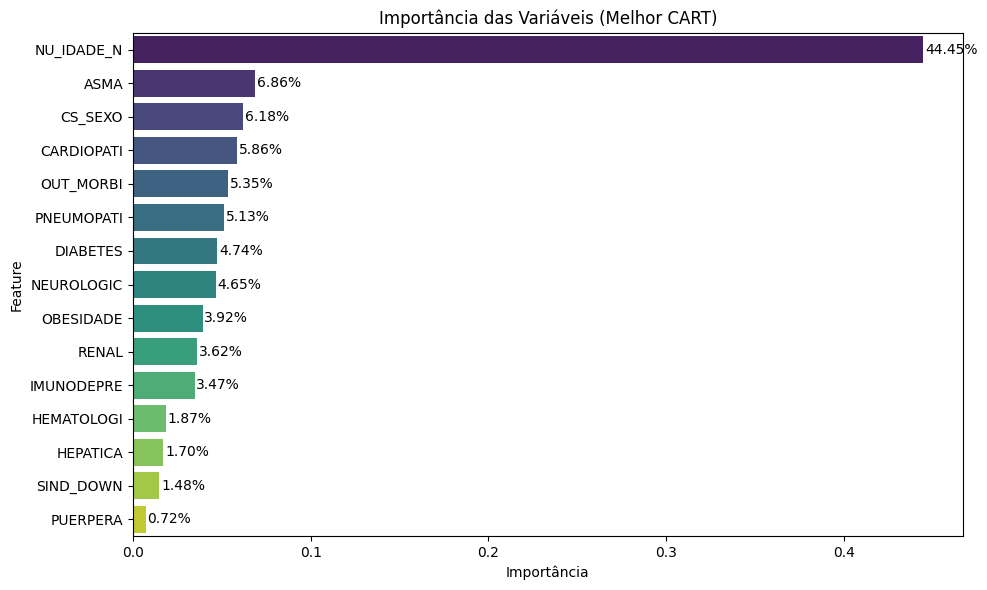

In [8]:
# 📌 7. Importância das features (do melhor modelo)
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
#sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis')
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis (Melhor CART)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

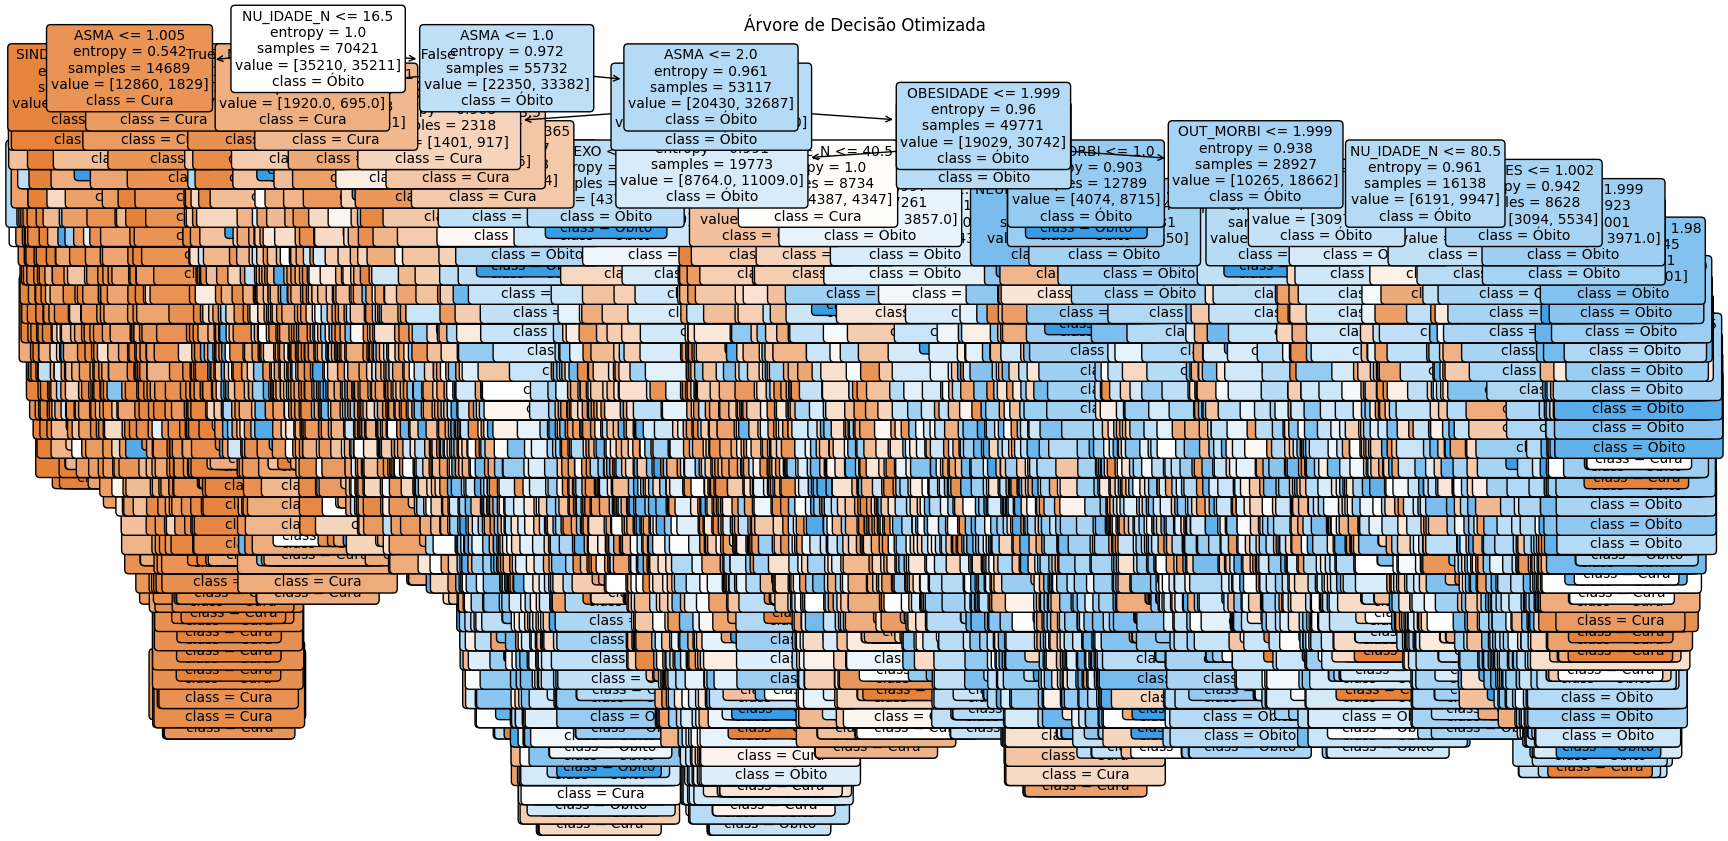

In [9]:
# 📌 8. Visualização da árvore (do melhor modelo)
plt.figure(figsize=(20,10))
plot_tree(best_clf, feature_names=X.columns, class_names=['Cura', 'Óbito'], filled=True, rounded=True, fontsize=10)
plt.title('Árvore de Decisão Otimizada')
plt.show()